# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects/hdiva', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# guidance weights

In [3]:
# load config and model
from b_models.ddpm.ddpm_module import DDPM
from b_models.configs.diva_config_modular import DiVA_ConvNet_dSprites_Training_Config

config = DiVA_ConvNet_dSprites_Training_Config()
ddpm = DDPM(config)

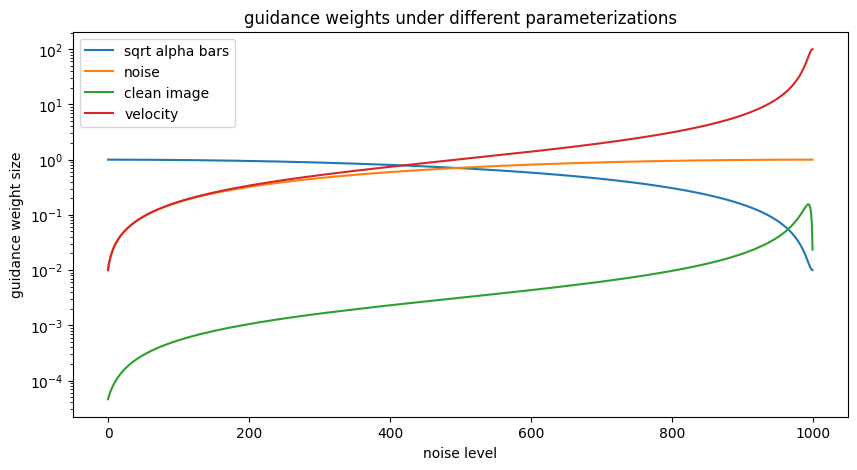

In [15]:
# let's plot the different parameterizations

# noise param
noise_weight = ddpm.sqrt_one_minus_alpha_bars

# clean image
alphas = ddpm.alphas
one_minus_alphas = 1 - alphas
sqrt_alphas = torch.sqrt(alphas)
clean_image_weight = one_minus_alphas / sqrt_alphas

# velocity param
sqrt_one_minus_alpha_bars = ddpm.sqrt_one_minus_alpha_bars
sqrt_alpha_bars = ddpm.sqrt_alpha_bars
velocity_weight = sqrt_one_minus_alpha_bars / sqrt_alpha_bars

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sqrt_alpha_bars, label="sqrt alpha bars")
ax.plot(noise_weight, label="noise")
ax.plot(clean_image_weight, label="clean image")
ax.plot(velocity_weight, label="velocity")
ax.set_title("guidance weights under different parameterizations")
ax.set_xlabel("noise level")
ax.set_ylabel("guidance weight size")
ax.legend()
# ylog
ax.set_yscale("log")
plt.show()


# normalized weights

In [ ]:
# let's plot the different parameterizations but normalized
